In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

In [10]:
df = pd.read_csv("/content/WineQT.csv")
print("First 3 rows of the dataset:")
print(df.head(3))
print("\nLast 3 rows of the dataset:")
print(df.tail(3))

First 3 rows of the dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  

Last 3 rows of the dataset:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2

In [11]:
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [26]:
print("Descriptive Statistics of the dataset:")
print(df.describe())

Descriptive Statistics of the dataset:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min      

In [27]:
print("\nChecking for missing values per column:")
print(pd.isna(df).any())


Checking for missing values per column:
fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
Id                      False
dtype: bool


In [28]:
print("\n missing values:")
print(df.isnull().sum())


 missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [13]:
mean_alcohol = df["alcohol"].mean()
median_alcohol = df["alcohol"].median()
mode_alcohol = df["alcohol"].mode()
print(f"Mean of alcohol: {mean_alcohol:.2f}")
print(f"Median of alcohol: {median_alcohol:.2f}")
print(f"Mode of alcohol: {mode_alcohol.to_list()}")

Mean of alcohol: 10.44
Median of alcohol: 10.20
Mode of alcohol: [9.5]


Value Counts for Wine Quality:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


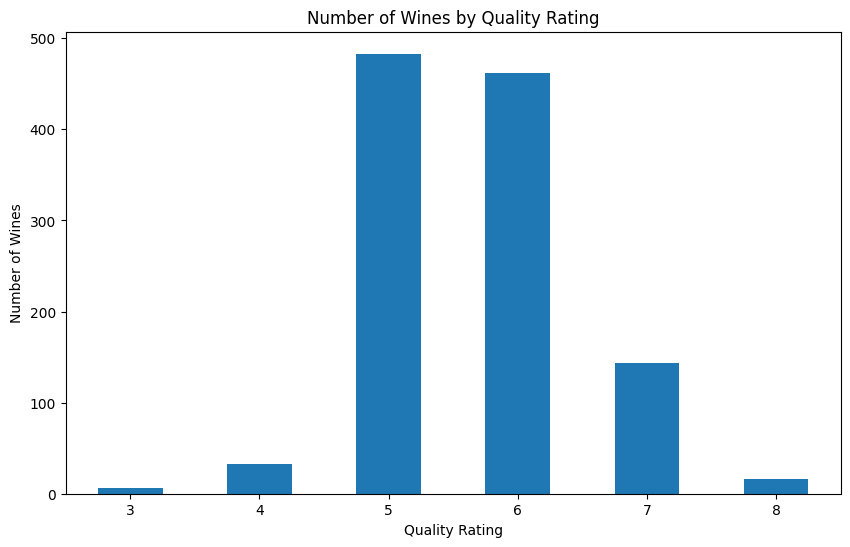

In [14]:
quality_counts = df['quality'].value_counts().sort_index()
print("Value Counts for Wine Quality:")
print(quality_counts)

plt.figure(figsize=(10, 6))
quality_counts.plot(kind='bar')
plt.title("Number of Wines by Quality Rating")
plt.ylabel('Number of Wines')
plt.xlabel('Quality Rating')
plt.xticks(rotation=0)
plt.show()

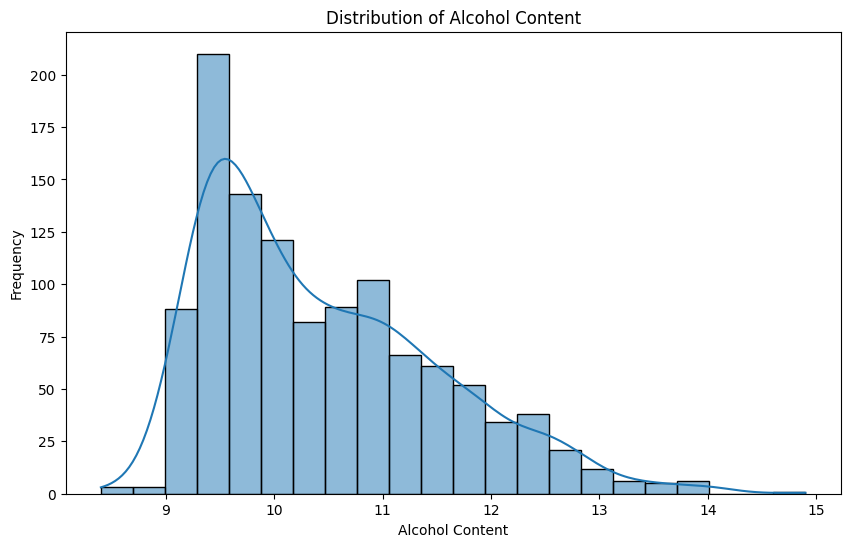

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df["alcohol"], kde=True)
plt.title("Distribution of Alcohol Content")
plt.xlabel("Alcohol Content")
plt.ylabel("Frequency")
plt.show()

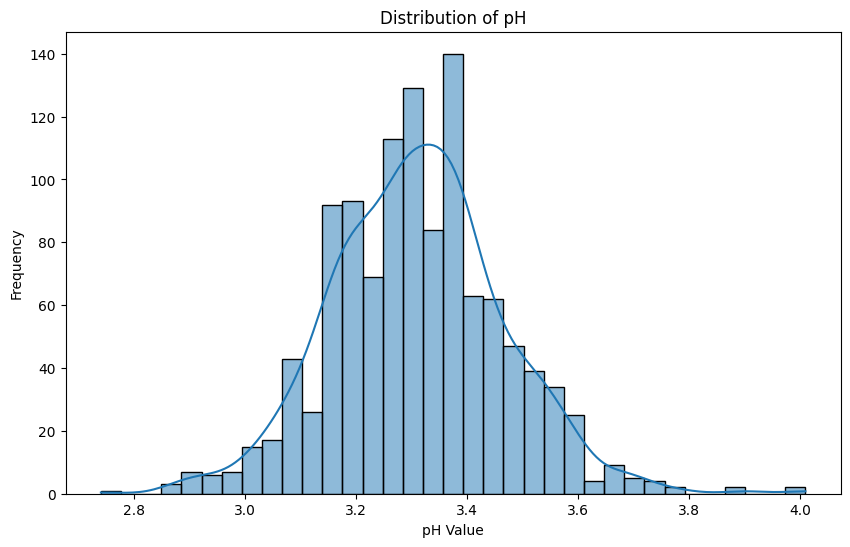

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df["pH"], kde=True)
plt.title("Distribution of pH")
plt.xlabel("pH Value")
plt.ylabel("Frequency")
plt.show()

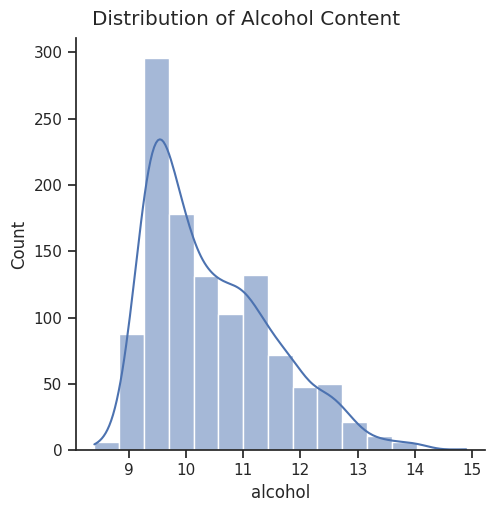

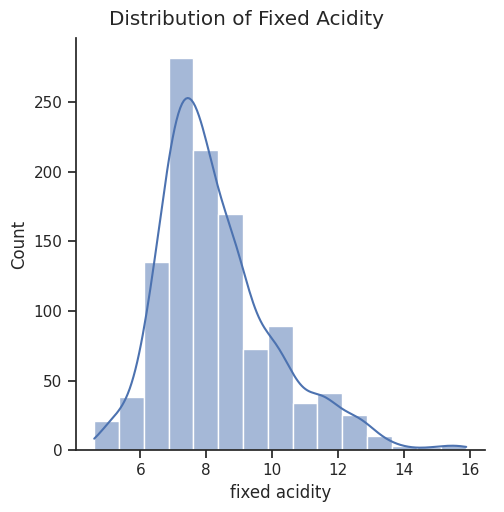

In [29]:
sns.FacetGrid(df, height=5).map(sns.histplot, "alcohol", kde=True, bins=15).add_legend()
plt.suptitle('Distribution of Alcohol Content', y=1.02)
plt.show()

sns.FacetGrid(df, height=5).map(sns.histplot, "fixed acidity", kde=True, bins=15).add_legend()
plt.suptitle('Distribution of Fixed Acidity', y=1.02)
plt.show()

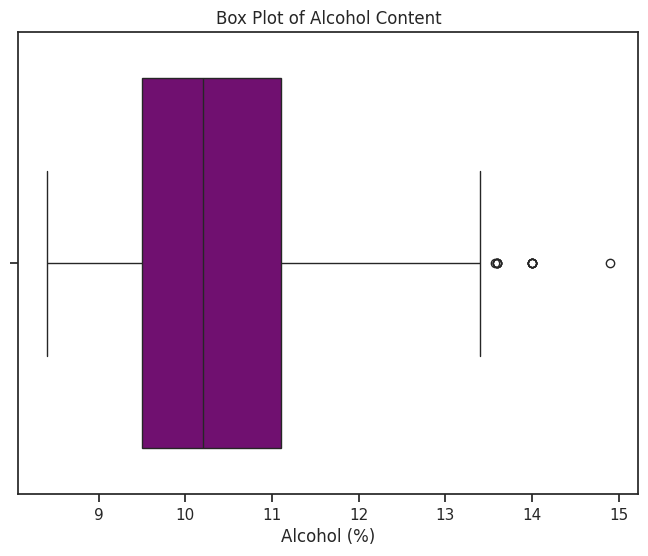

In [30]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="alcohol", data=df, color='purple')
plt.title("Box Plot of Alcohol Content")
plt.xlabel("Alcohol (%)")
plt.show()

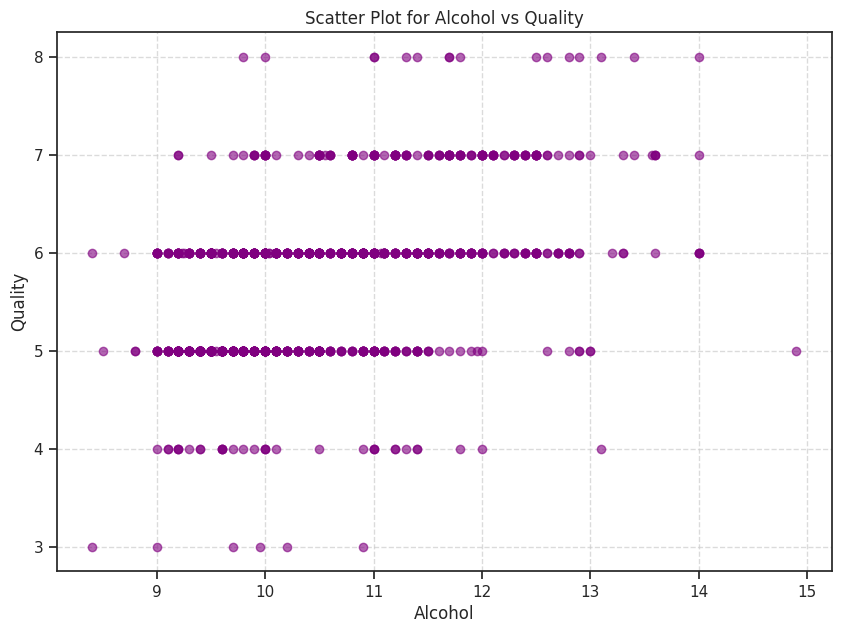

In [31]:
plt.figure(figsize=(10, 7))
plt.scatter(df["alcohol"], df["quality"], alpha=0.6, color='purple')

plt.title("Scatter Plot for Alcohol vs Quality")

plt.xlabel("Alcohol")

plt.ylabel("Quality")

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

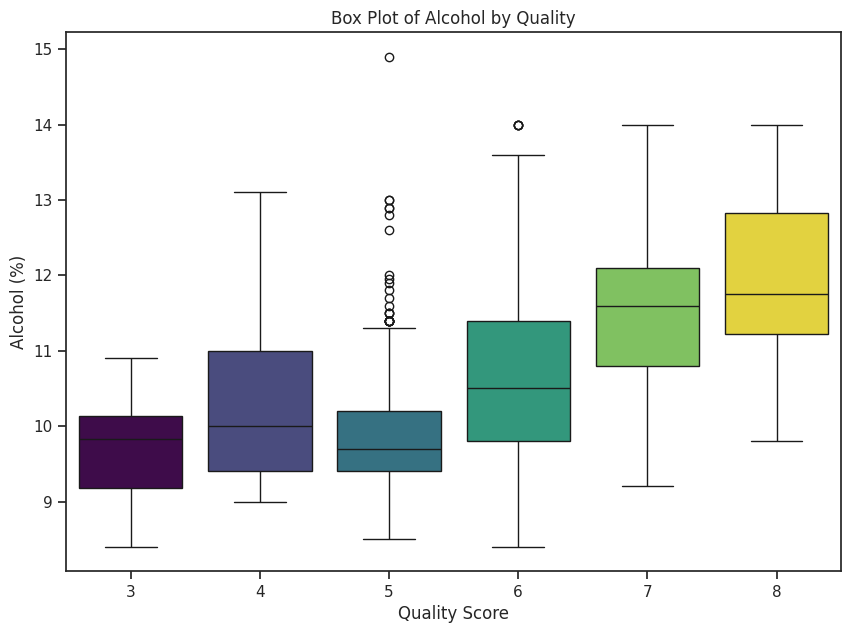

In [32]:
plt.figure(figsize=(10, 7))
sns.boxplot(x="quality", y="alcohol", data=df, palette='viridis', hue="quality", legend=False)

plt.title("Box Plot of Alcohol by Quality")
plt.xlabel("Quality Score")
plt.ylabel("Alcohol (%)")

plt.show()

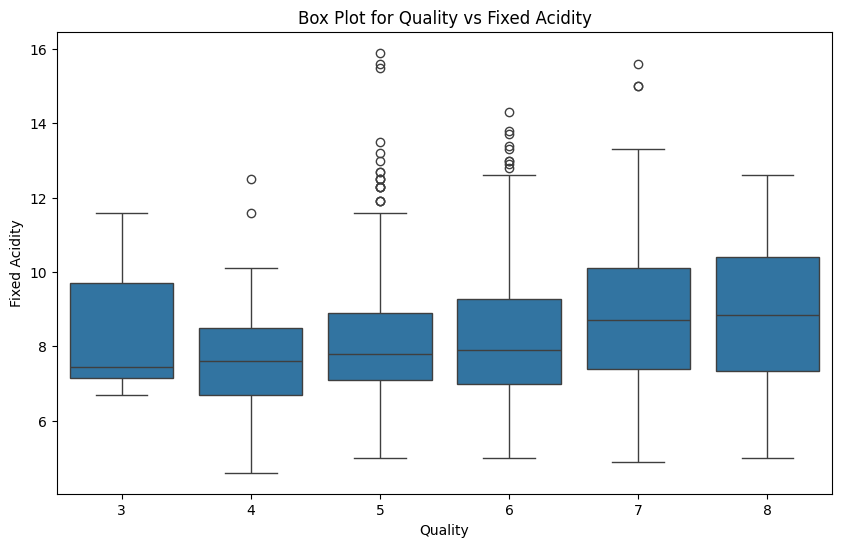

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="quality", y="fixed acidity", data=df)
plt.title("Box Plot for Quality vs Fixed Acidity")
plt.xlabel("Quality")
plt.ylabel("Fixed Acidity")
plt.show()

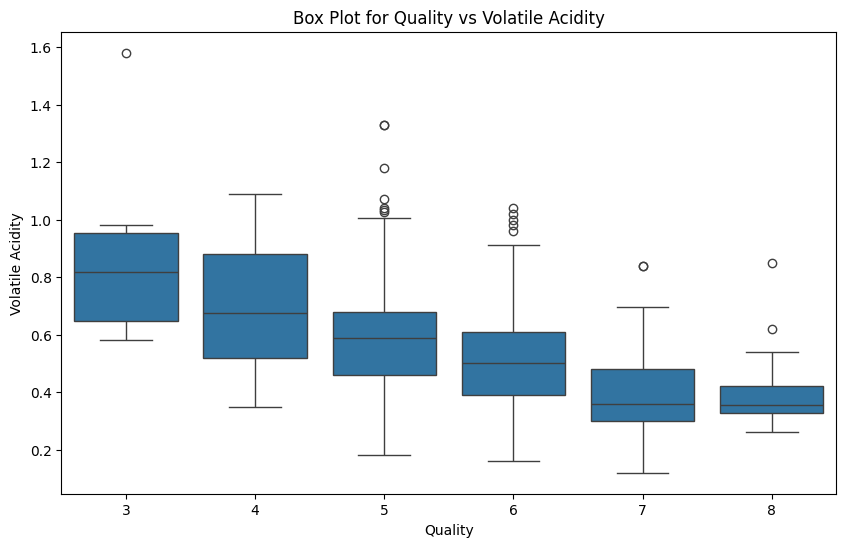

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="quality", y="volatile acidity", data=df)
plt.title("Box Plot for Quality vs Volatile Acidity")
plt.xlabel("Quality")
plt.ylabel("Volatile Acidity")
plt.show()

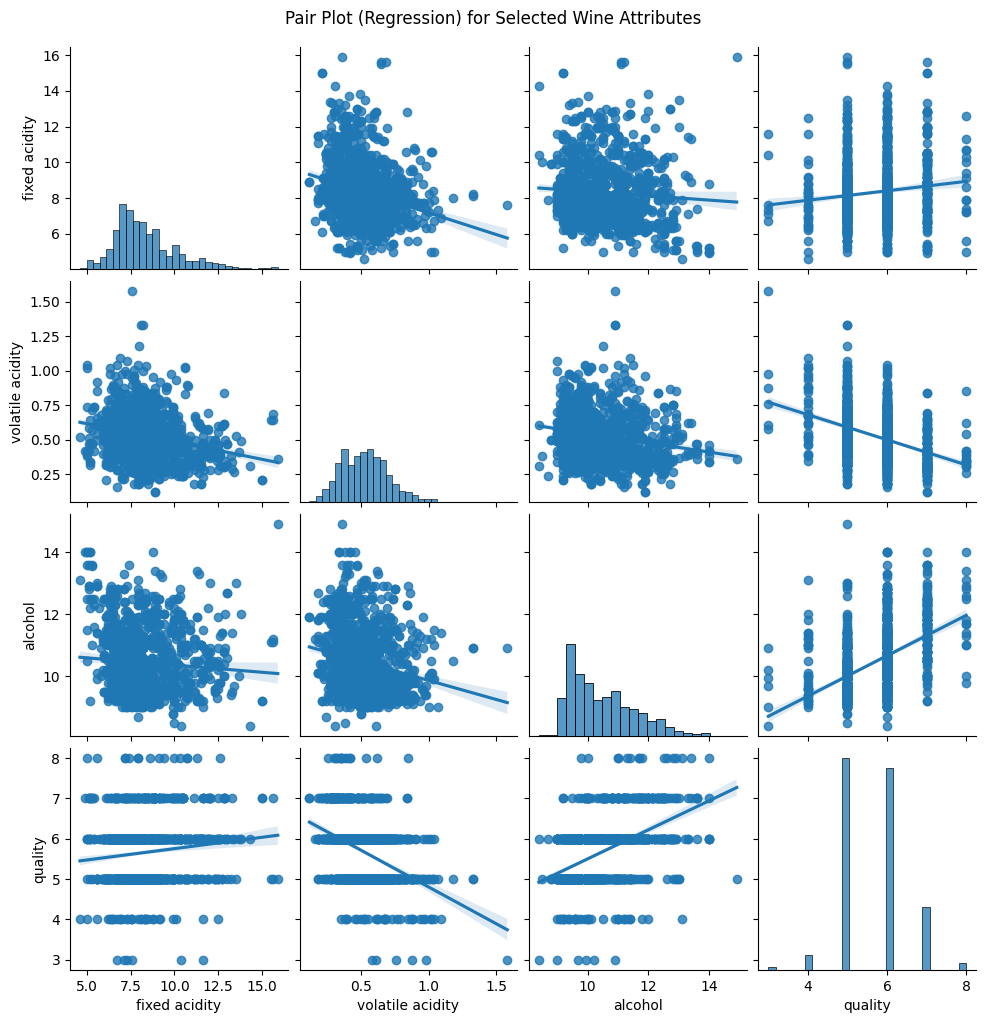

In [21]:
sns.pairplot(df, vars=['fixed acidity', 'volatile acidity', 'alcohol', 'quality'], kind="reg")
plt.suptitle("Pair Plot (Regression) for Selected Wine Attributes", y=1.02)
plt.show()

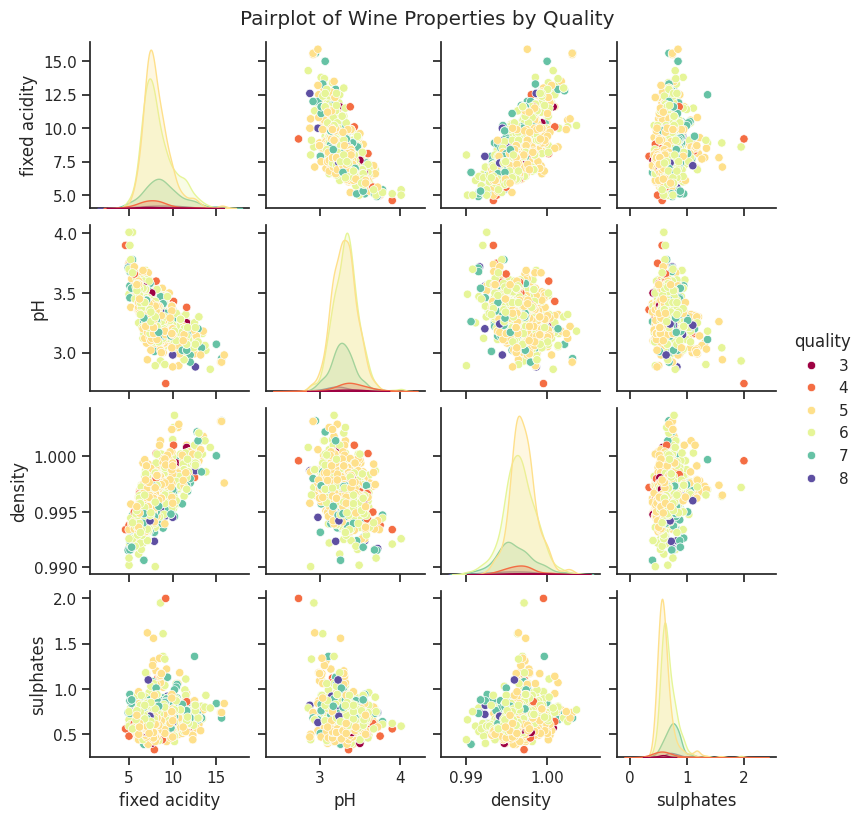

In [33]:
sns.set(style="ticks", color_codes=True)

sns.pairplot(df, height=2, vars=['fixed acidity', 'pH', 'density', 'sulphates'], hue="quality", palette='Spectral')

plt.suptitle('Pairplot of Wine Properties by Quality', y=1.02)
plt.show()

In [23]:
corr_alcohol_quality = stats.pearsonr(df["alcohol"], df["quality"])
print("Pearson Correlation for Alcohol and Quality:")
print(f"p-value:\t {corr_alcohol_quality[1]:.3f}")
print(f"Correlation:\t {corr_alcohol_quality[0]:.3f}")

Pearson Correlation for Alcohol and Quality:
p-value:	 0.000
Correlation:	 0.485


In [24]:
print("Correlation matrix for numerical records in WineQT.csv:")
correlation = df.corr(method='pearson', numeric_only=True)
print(correlation)

Correlation matrix for numerical records in WineQT.csv:
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   
Id                        -0.27582

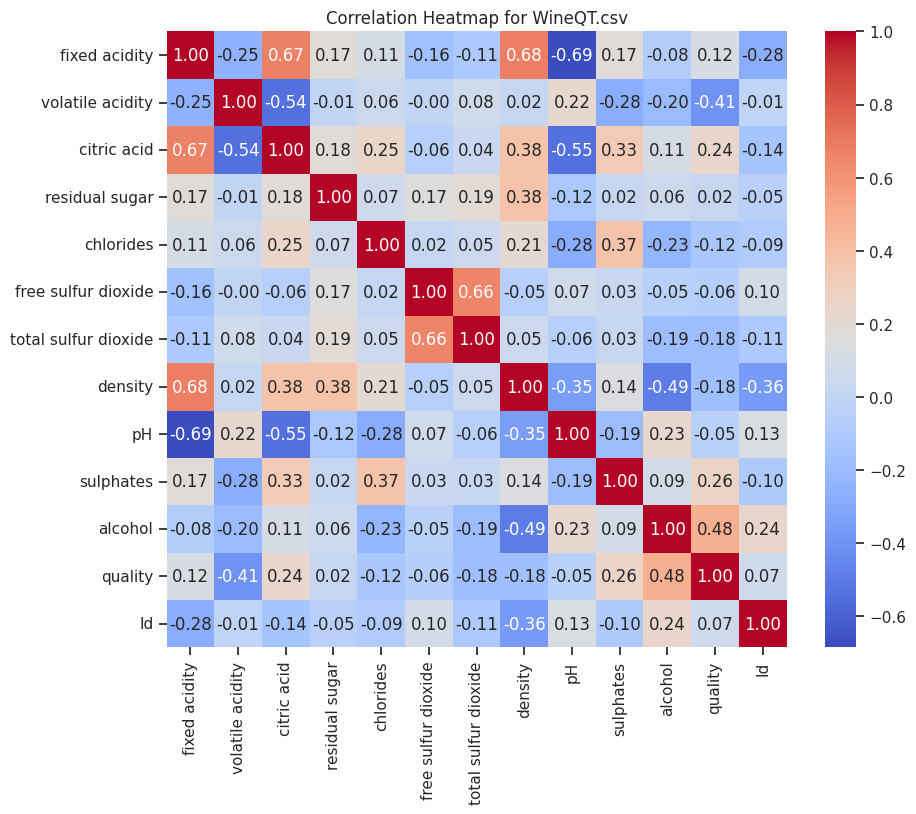

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for WineQT.csv')
plt.show()